<H1>COMP4531 Deep Learning Mid-Term</H1>

In this project, we will be developing a basic neural network from the ground up to classify various types of fashion items. The primary objective of this project is to gain a comprehensive understanding of neural network architecture, including its theory and implementation details.

Categories in the dataset:

    0: T-shirt/top
    1: Trouser
    2: Pullover
    3: Dress
    4: Coat
    5: Sandal
    6: Shirt
    7: Sneaker
    8: Bag
    9: Ankle boot


<H2>Part 0: Initialization</H2>

To start, let's load some packages and the dataset

In [3]:
# Notice that you don't need any other packages for this mid-term

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

np.random.seed(42) # NEVER change this line; this is for grading

In [4]:
# Reading the dataset
data = pd.read_csv('./fashion_data.csv')

In [5]:
# The data pre-processing is done for you. Please do NOT edit the cell
# However, you should understand what these codes are doing

data = np.array(data)
m, n = data.shape
np.random.shuffle(data) # shuffle before splitting into dev and training sets

data_dev = data[0:400].T
Y_dev = data_dev[-1]
X_dev = data_dev[0:n-1]
X_dev = X_dev / 255.

data_train = data[400:m].T
Y_train = data_train[-1]
X_train = data_train[0:n-1]
X_train = X_train / 255.
_,m_train = X_train.shape

In [6]:
Y_train

array([0, 0, 7, ..., 5, 2, 2])

In [7]:
X_dev.shape

(784, 400)

In [8]:
X_train.shape

(784, 1600)

In [9]:
print(m,n)

2000 785


<H2>Part 1: Building your own neural network</H2>

In [10]:
# define a global variable specifying the number of hidden neurons after the first layer
# not the best practice, but we will do it for this mid-term project
num_hidden_neurons = 20

This is the main part of the mid-term. You **must not** change the definition of the function. In fact, the comments are going to help you go through the implementation and they are all you need

<H3>1.1 Initialize the parameter in the neural network</H3>

In [12]:
# Initialize the parameters in the neural network

# We need the weight and bias matrices. 
# W1, b1 are the matrices for the first layer
# W2, b2 are the matrices for the second layer

# You should think about the sizes of the matrices
# then initialize elements in the matrix to be random numbers between -0.5 to +0.5

def init_params():
    """
    Initialize network parameters for a 2-layer fully connected neural network.
    Shapes are based on:
        Input layer: 784 neurons (28x28 pixels)
        Hidden layer: 20 neurons (num_hidden_neurons)
        Output layer: 10 neurons (10 Fashion-MNIST classes)

    Returns
    -------
    W1, b1, W2, b2 : np.ndarray
        Randomly initialized weights and zero biases.
    """
    # layer dimensions
    n_input = 784              # number of input features
    n_hidden = 20              # number of hidden neurons
    n_output = 10              # number of output classes

    # initialize parameters with values in range [-0.5, 0.5]
    W1 = np.random.rand(n_hidden, n_input) - 0.5
    b1 = np.random.rand(n_hidden, 1) - 0.5
    W2 = np.random.rand(n_output, n_hidden) - 0.5
    b2 = np.random.rand(n_output, 1) - 0.5

    return W1, b1, W2, b2

<H3>1.2 Implement the non-linearity functions and its derivatives</H3>

In [13]:
# As a starting point, you only need a ReLu function, its derivative, and the softmax function 

def ReLU(Z):
    """
    Apply the ReLU (Rectified Linear Unit) activation function elementwise.

    Parameters
    ----------
    Z : np.ndarray
        Pre-activation values (can be of any shape).

    Returns
    -------
    A : np.ndarray
        Post-activation output, where all negative values are set to 0.
    """
    A = np.maximum(0, Z)
    return A

def ReLU_deriv(Z):
    """
    Compute the derivative of ReLU with respect to its input Z.

    Parameters
    ----------
    Z : np.ndarray
        Pre-activation values.

    Returns
    -------
    dZ : np.ndarray
        Derivative of ReLU:
        1 for Z > 0, 0 otherwise.
    """
    dZ = (Z > 0).astype(float)
    return dZ

def softmax(Z):
    """
    Compute the softmax activation function across each column (class scores).

    Parameters
    ----------
    Z : np.ndarray
        Pre-activation scores, shape (num_classes, m)

    Returns
    -------
    A : np.ndarray
        Softmax probabilities, same shape as Z.
    """
    # Subtract max from each column for numerical stability
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    A = exp_Z / np.sum(exp_Z, axis=0, keepdims=True)
    return A

<H3>1.3 Implement the forward propagation function</H3>

In [14]:
# In the forward propagation function, X is the inputs (the image in vector form), and we pass all the weights and biases

def forward_prop(W1, b1, W2, b2, X):
    """
    Perform forward propagation through a 2-layer neural network.

    Parameters
    ----------
    W1, b1 : np.ndarray
        Weight and bias for hidden layer (W1: [20x784], b1: [20x1]).
    W2, b2 : np.ndarray
        Weight and bias for output layer (W2: [10x20], b2: [10x1]).
    X : np.ndarray
        Input data, shape (784, m), where m = number of examples.

    Returns
    -------
    Z1 : np.ndarray
        Linear combination (hidden layer pre-activation)
    A1 : np.ndarray
        Activation from hidden layer after ReLU
    Z2 : np.ndarray
        Linear combination (output layer pre-activation)
    A2 : np.ndarray
        Softmax probabilities for output layer
    """
    # Hidden layer linear step
    Z1 = np.dot(W1, X) + b1
    
    # Hidden layer activation (ReLU)
    A1 = ReLU(Z1)
    
    # Output layer linear step
    Z2 = np.dot(W2, A1) + b2
    
    # Output activation (Softmax for probabilities)
    A2 = softmax(Z2)
    
    return Z1, A1, Z2, A2

<H3>1.4 Implement the backward propagation function</H3>

In [15]:
# This one hot function is to convert a numeric number into a one-hot vector
def one_hot(Y):
    """
    Convert numeric labels into one-hot encoded vectors.
    
    Parameters
    ----------
    Y : np.ndarray
        Array of integer class labels, shape (m,)

    Returns
    -------
    one_hot_Y : np.ndarray
        One-hot encoded labels, shape (num_classes, m)
    """
    one_hot_Y = np.zeros((10, Y.size))      # 10 classes in Fashion-MNIST
    one_hot_Y[Y, np.arange(Y.size)] = 1     # set 1 at correct class index
    return one_hot_Y

# Now performing the backward propagation
# Each function is only one line, but lots of Calculus behind 
def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    """
    Perform backward propagation for a 2-layer NN.

    Parameters
    ----------
    Z1, A1, Z2, A2 : np.ndarray
        Intermediate results from forward_prop
    W1, W2 : np.ndarray
        Weight matrices
    X : np.ndarray
        Input features, shape (784, m)
    Y : np.ndarray
        True labels, shape (m,)

    Returns
    -------
    dW1, db1, dW2, db2 : np.ndarray
        Gradients of loss w.r.t parameters
    """
    m = X.shape[1]
    one_hot_Y = one_hot(Y)
    
    # Output layer gradients
    dZ2 = A2 - one_hot_Y
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    # Hidden layer gradients
    dZ1 = np.dot(W2.T, dZ2) * ReLU_deriv(Z1)
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

# Finally, we are ready to update the parameters
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    """
    Update parameters using gradient descent.

    Parameters
    ----------
    W1, b1, W2, b2 : np.ndarray
        Current parameters
    dW1, db1, dW2, db2 : np.ndarray
        Gradients
    alpha : float
        Learning rate

    Returns
    -------
    Updated W1, b1, W2, b2
    """
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

<H3>1.5 Performing the gradient descent</H3>

In [16]:
# Implement the helper function. We need to convert the softmax output into a numeric label 
# This is done through get_predictions function
def get_predictions(A2):
    """
    Convert softmax probabilities to class label predictions.

    Parameters
    ----------
    A2 : np.ndarray
        Softmax output of shape (10, m)

    Returns
    -------
    predictions : np.ndarray
        Vector of predicted class indices, shape (m,)
    """
    predictions = np.argmax(A2, axis=0)
    return predictions

# We also want to have a simple function to compute the accuracy. Notice that "predictions" and "Y" are the same shape
def get_accuracy(predictions, Y):
    """
    Compute prediction accuracy as the proportion of correct labels.

    Parameters
    ----------
    predictions : np.ndarray
        Predicted class labels (m,)
    Y : np.ndarray
        True class labels (m,)

    Returns
    -------
    accuracy : float
        Accuracy value in [0,1]
    """
    return np.mean(predictions == Y)

# Finally, we are ready to implement gradient descent
def gradient_descent(X, Y, alpha, iterations):
    """
    Perform gradient descent to train the 2-layer neural network.

    Parameters
    ----------
    X : np.ndarray
        Input features, shape (784, m)
    Y : np.ndarray
        True labels, shape (m,)
    alpha : float
        Learning rate
    iterations : int
        Number of training iterations

    Returns
    -------
    W1, b1, W2, b2 : np.ndarray
        Trained parameters
    """
    # Step 1: Initialize parameters
    W1, b1, W2, b2 = init_params()

    # Step 2: Training loop
    for i in range(iterations):
        # Forward propagation
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        
        # Backward propagation
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        
        # Parameter update
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        # Monitor progress every 10 iterations
        if i % 10 == 0:
            print("Iteration:", i)
            predictions = get_predictions(A2)
            print(get_accuracy(predictions, Y))

    return W1, b1, W2, b2

In [17]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration: 0
0.07
Iteration: 10
0.309375
Iteration: 20
0.424375
Iteration: 30
0.536875
Iteration: 40
0.5875
Iteration: 50
0.615
Iteration: 60
0.634375
Iteration: 70
0.651875
Iteration: 80
0.66875
Iteration: 90
0.678125
Iteration: 100
0.685
Iteration: 110
0.700625
Iteration: 120
0.70875
Iteration: 130
0.715
Iteration: 140
0.721875
Iteration: 150
0.7225
Iteration: 160
0.729375
Iteration: 170
0.73
Iteration: 180
0.735625
Iteration: 190
0.7425
Iteration: 200
0.74125
Iteration: 210
0.733125
Iteration: 220
0.735
Iteration: 230
0.74
Iteration: 240
0.75125
Iteration: 250
0.75625
Iteration: 260
0.75875
Iteration: 270
0.76125
Iteration: 280
0.765
Iteration: 290
0.7675
Iteration: 300
0.770625
Iteration: 310
0.775625
Iteration: 320
0.7775
Iteration: 330
0.783125
Iteration: 340
0.785
Iteration: 350
0.78875
Iteration: 360
0.79
Iteration: 370
0.79125
Iteration: 380
0.79375
Iteration: 390
0.7975
Iteration: 400
0.800625
Iteration: 410
0.8
Iteration: 420
0.801875
Iteration: 430
0.80375
Iteration: 440
0.

<H3>1.6 Validation Set Performance</H3>

In [18]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

In [19]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

0.7875

<H3>1.7 Exploring some samples</H3>

Prediction:  [0]
Label:  0


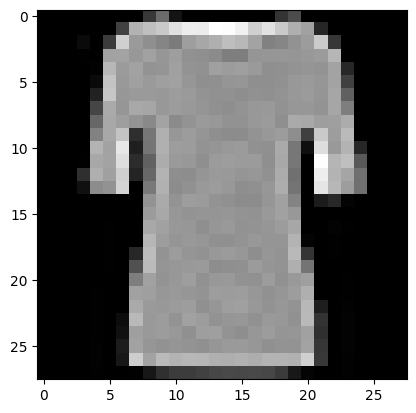

Prediction:  [3]
Label:  0


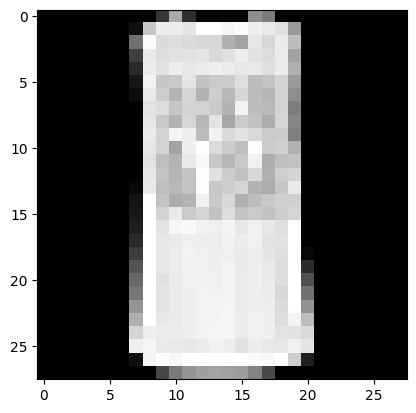

Prediction:  [7]
Label:  7


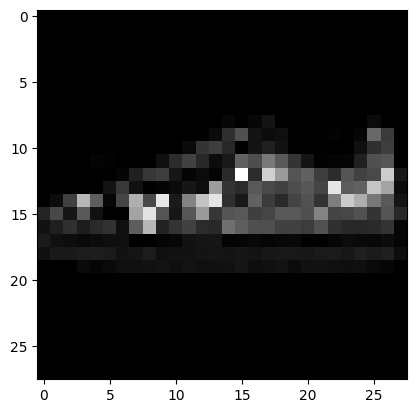

Prediction:  [3]
Label:  3


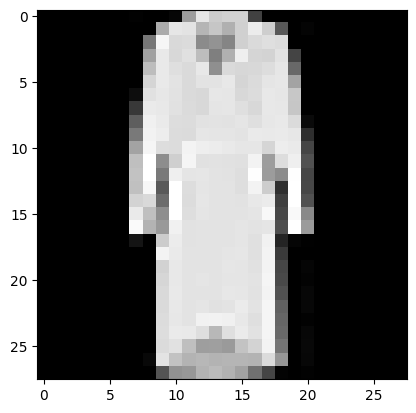

In [20]:
def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()
    
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(50, W1, b1, W2, b2)

<H2>Part 2: Error Analysis and Performance Improvements</H2>

You now will try to improve the model performance through, for example, different activation functions, learning rate cahnges, expanding the network complexity, regularization, and dropouts.  Implement these ideas for improvement and compare to the base model you completed in part 1.  The ideas may not improve the model, they may improve, give reasons why you did or did not succeed in makeing a better model.  You must implement at least three different models.

**It is crucial to provide reasoning behind what you do, or else no credit will be given.**

In [22]:
# Utilities:
# - one_hot(Y)
# - ReLU(Z), ReLU_deriv(Z), softmax(Z)
# - forward_prop(...), backward_prop(...), update_params(...)
# - get_predictions(A2), get_accuracy(pred, Y)
# - gradient_descent(X, Y, alpha, iterations)

# ---------- New: Additional activations ----------
def leaky_relu(Z, alpha=0.01):
    """Leaky ReLU activation to reduce 'dying ReLU' (keeps small gradient for Z<0)."""
    return np.where(Z > 0, Z, alpha * Z)

def d_leaky_relu(Z, alpha=0.01):
    """Derivative of Leaky ReLU."""
    d = np.ones_like(Z)
    d[Z < 0] = alpha
    return d

def tanh_act(Z):
    """Tanh activation (use with Xavier init)."""
    return np.tanh(Z)

def d_tanh_act(Z):
    """Derivative of tanh wrt pre-activation."""
    T = np.tanh(Z)
    return 1.0 - T**2

# ---------- New: Flexible initializer (He or Xavier) ----------
def init_params_flex(n_input=784, n_hidden=128, n_output=10, activation='relu', seed=4531):
    """
    Initialize weights/biases for 1-hidden-layer MLP with appropriate scaling.
    He init for ReLU/LeakyReLU; Xavier for tanh/sigmoid.
    """
    rng = np.random.default_rng(seed)
    if activation in ('relu', 'leaky_relu'):
        w1_std = np.sqrt(2.0 / n_input)   # He
    else:
        w1_std = np.sqrt(1.0 / n_input)   # Xavier (simple)

    w2_std = np.sqrt(1.0 / n_hidden)      # conservative for output

    W1 = rng.normal(0, w1_std, size=(n_hidden, n_input)).astype(np.float32)
    b1 = np.zeros((n_hidden, 1), dtype=np.float32)
    W2 = rng.normal(0, w2_std, size=(n_output, n_hidden)).astype(np.float32)
    b2 = np.zeros((n_output, 1), dtype=np.float32)
    return W1, b1, W2, b2

# ---------- New: Forward pass with selectable activation + dropout ----------
def forward_prop_variant(W1, b1, W2, b2, X, activation='relu', keep_prob=1.0, rng=None):
    """
    Forward pass for 1-hidden-layer MLP with optional dropout on hidden activations.

    Parameters
    ----------
    activation : {'relu','leaky_relu','tanh'}
    keep_prob : float in (0,1], probability of keeping a hidden activation (1.0 disables dropout)
    rng : np.random.Generator or None for deterministic path
    """
    # Hidden linear
    Z1 = np.dot(W1, X) + b1

    # Hidden activation
    if activation == 'relu':
        A1 = ReLU(Z1)
    elif activation == 'leaky_relu':
        A1 = leaky_relu(Z1, alpha=0.01)
    elif activation == 'tanh':
        A1 = tanh_act(Z1)
    else:
        raise ValueError("Unsupported activation")

    # Dropout (inverted) on hidden layer
    mask = None
    if keep_prob < 1.0:
        if rng is None:
            rng = np.random.default_rng(123)
        mask = (rng.random(A1.shape) < keep_prob).astype(np.float32)
        A1 = (A1 * mask) / keep_prob  # inverted dropout scaling

    # Output linear + softmax
    Z2 = np.dot(W2, A1) + b2
    A2 = softmax(Z2)
    cache = {"X": X, "Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "mask": mask}
    return cache, A2

# ---------- New: Backward pass with activation choice, L2, dropout ----------
def backward_prop_variant(cache, W1, W2, Y, activation='relu', l2=0.0):
    """
    Backprop for 1-hidden-layer MLP with selectable activation, L2 regularization,
    and dropout mask from the forward pass.
    """
    X, Z1, A1, Z2, A2, mask = cache["X"], cache["Z1"], cache["A1"], cache["Z2"], cache["A2"], cache["mask"]
    m = X.shape[1]
    one_hot_Y = one_hot(Y)

    # Output layer
    dZ2 = (A2 - one_hot_Y)                      # (10, m)
    dW2 = (1.0 / m) * np.dot(dZ2, A1.T) + l2 * W2
    db2 = (1.0 / m) * np.sum(dZ2, axis=1, keepdims=True)

    # Hidden layer
    dA1 = np.dot(W2.T, dZ2)                     # (H, m)

    # Undo dropout scaling if used
    if mask is not None:
        keep_prob = (mask.sum() / mask.size) * (mask.size / mask.size)  # not needed; kept for clarity
        dA1 = (dA1 * mask) / (np.mean(mask) + 1e-12)  # consistent with inverted dropout

    if activation == 'relu':
        dZ1 = dA1 * ReLU_deriv(Z1)
    elif activation == 'leaky_relu':
        dZ1 = dA1 * d_leaky_relu(Z1, alpha=0.01)
    elif activation == 'tanh':
        dZ1 = dA1 * d_tanh_act(Z1)
    else:
        raise ValueError("Unsupported activation")

    dW1 = (1.0 / m) * np.dot(dZ1, X.T) + l2 * W1
    db1 = (1.0 / m) * np.sum(dZ1, axis=1, keepdims=True)

    return dW1, db1, dW2, db2

# ---------- New: Momentum + LR decay trainer for variants ----------
def train_variant(
    X, Y, X_dev, Y_dev,
    n_hidden=128, activation='relu',
    alpha=0.12, iterations=300, batch_size=None,
    l2=1e-4, keep_prob=1.0,
    momentum=0.9, lr_decay=0.99,
    seed=2025, verbose_every=25
):
    """
    Train a 1-hidden-layer model with options for activation, width, L2, dropout, momentum, and LR decay.

    Notes
    -----
    - Uses full-batch GD by default (batch_size=None). Set batch_size to int to enable mini-batch.
    - LR decay: alpha_t = alpha_0 * (lr_decay ** t)
    - Momentum: classical velocity update
    """
    rng = np.random.default_rng(seed)
    W1, b1, W2, b2 = init_params_flex(784, n_hidden, 10, activation=activation, seed=seed)

    # momentum buffers
    vW1 = np.zeros_like(W1); vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2); vb2 = np.zeros_like(b2)

    history = {"train_acc": [], "dev_acc": [], "lr": []}
    curr_alpha = alpha

    def batches(X, Y, batch_size):
        if batch_size is None:
            yield X, Y
            return
        m = X.shape[1]
        idx = np.arange(m)
        rng.shuffle(idx)
        for start in range(0, m, batch_size):
            sl = idx[start:start+batch_size]
            yield X[:, sl], Y[sl]

    for it in range(1, iterations+1):
        # mini-batch or full-batch
        for Xb, Yb in batches(X, Y, batch_size):
            cache, A2 = forward_prop_variant(W1, b1, W2, b2, Xb, activation=activation, keep_prob=keep_prob, rng=rng)
            dW1, db1, dW2, db2 = backward_prop_variant(cache, W1, W2, Yb, activation=activation, l2=l2)

            # momentum update
            vW1 = momentum * vW1 - curr_alpha * dW1
            vb1 = momentum * vb1 - curr_alpha * db1
            vW2 = momentum * vW2 - curr_alpha * dW2
            vb2 = momentum * vb2 - curr_alpha * db2

            W1 += vW1; b1 += vb1
            W2 += vW2; b2 += vb2

        # metrics each iteration (full forward on train/dev)
        _, A2_train = forward_prop_variant(W1, b1, W2, b2, X, activation=activation, keep_prob=1.0)
        train_acc = get_accuracy(get_predictions(A2_train), Y)

        _, A2_dev = forward_prop_variant(W1, b1, W2, b2, X_dev, activation=activation, keep_prob=1.0)
        dev_acc = get_accuracy(get_predictions(A2_dev), Y_dev)

        history["train_acc"].append(float(train_acc))
        history["dev_acc"].append(float(dev_acc))
        history["lr"].append(float(curr_alpha))

        # decay learning rate
        curr_alpha *= lr_decay

        if it % (verbose_every or 999999) == 0:
            print(f"[{activation:10s} | H={n_hidden:3d}] iter={it:03d}  lr={history['lr'][-1]:.4f}  "
                  f"train_acc={train_acc:.3f}  dev_acc={dev_acc:.3f}")

    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
    return params, history

def plot_histories(histories, title="Dev Accuracy over Iterations"):
    """Plot dev accuracy for multiple runs."""
    plt.figure(figsize=(7.5,4))
    for name, h in histories.items():
        plt.plot(h["dev_acc"], label=name)
    plt.xlabel("iteration"); plt.ylabel("dev accuracy"); plt.title(title); plt.legend(); plt.tight_layout(); plt.show()


[relu       | H=128] iter=025  lr=0.0943  train_acc=0.719  dev_acc=0.733
[relu       | H=128] iter=050  lr=0.0733  train_acc=0.821  dev_acc=0.815
[relu       | H=128] iter=075  lr=0.0570  train_acc=0.875  dev_acc=0.838
[relu       | H=128] iter=100  lr=0.0444  train_acc=0.895  dev_acc=0.840
[relu       | H=128] iter=125  lr=0.0345  train_acc=0.916  dev_acc=0.840
[relu       | H=128] iter=150  lr=0.0268  train_acc=0.927  dev_acc=0.833
[relu       | H=128] iter=175  lr=0.0209  train_acc=0.933  dev_acc=0.833
[relu       | H=128] iter=200  lr=0.0162  train_acc=0.939  dev_acc=0.828
[relu       | H=128] iter=225  lr=0.0126  train_acc=0.943  dev_acc=0.830
[relu       | H=128] iter=250  lr=0.0098  train_acc=0.944  dev_acc=0.830
[tanh       | H=128] iter=025  lr=0.0629  train_acc=0.778  dev_acc=0.802
[tanh       | H=128] iter=050  lr=0.0489  train_acc=0.844  dev_acc=0.840
[tanh       | H=128] iter=075  lr=0.0380  train_acc=0.863  dev_acc=0.843
[tanh       | H=128] iter=100  lr=0.0296  train_acc

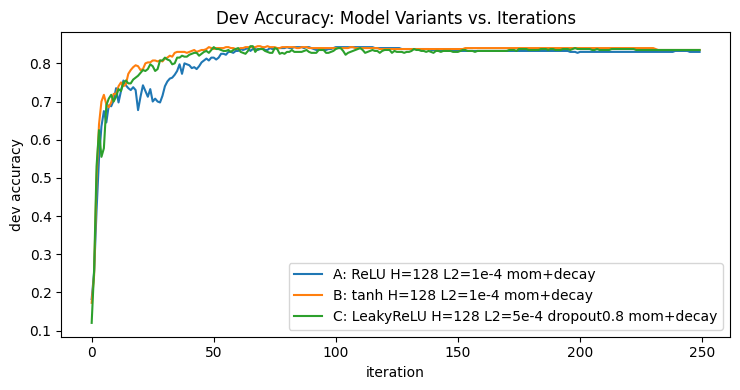

A: ReLU H=128 L2=1e-4 mom+decay               -> final dev acc = 0.830
B: tanh H=128 L2=1e-4 mom+decay               -> final dev acc = 0.835
C: LeakyReLU H=128 L2=5e-4 dropout0.8 mom+decay -> final dev acc = 0.835


In [23]:
# ----- Compare to your base model (~0.7875 dev acc) -----
histories = {}

# Model A: ReLU + width + momentum + decay + L2
params_A, hist_A = train_variant(
    X_train, Y_train, X_dev, Y_dev,
    n_hidden=128, activation='relu',
    alpha=0.12, iterations=250,
    l2=1e-4, keep_prob=1.0,
    momentum=0.9, lr_decay=0.99,
    seed=2025, verbose_every=25
)
histories["A: ReLU H=128 L2=1e-4 mom+decay"] = hist_A

# Model B: tanh + Xavier + slightly smaller LR
params_B, hist_B = train_variant(
    X_train, Y_train, X_dev, Y_dev,
    n_hidden=128, activation='tanh',
    alpha=0.08, iterations=250,
    l2=1e-4, keep_prob=1.0,
    momentum=0.9, lr_decay=0.99,
    seed=2026, verbose_every=25
)
histories["B: tanh H=128 L2=1e-4 mom+decay"] = hist_B

# Model C: LeakyReLU + Dropout + stronger L2
params_C, hist_C = train_variant(
    X_train, Y_train, X_dev, Y_dev,
    n_hidden=128, activation='leaky_relu',
    alpha=0.12, iterations=250,
    l2=5e-4, keep_prob=0.8,   # dropout ON
    momentum=0.9, lr_decay=0.99,
    seed=2027, verbose_every=25
)
histories["C: LeakyReLU H=128 L2=5e-4 dropout0.8 mom+decay"] = hist_C

# Plot dev accuracy trajectories
plot_histories(histories, title="Dev Accuracy: Model Variants vs. Iterations")

# Print final dev accuracies for quick comparison
for name, h in histories.items():
    print(f"{name:45s} -> final dev acc = {h['dev_acc'][-1]:.3f}")


## Model Improvement and Comparative Analysis

### Objective
In this section, we aim to **improve the base model** (~0.7875 dev accuracy) through several architectural and optimization changes.  
The goal is to explore whether these changes lead to higher accuracy, faster convergence, or better generalization.

---

### Experimental Setup
We implemented three different model configurations using the same training and dev datasets:

| Model | Activation | Hidden Units | Regularization | Dropout | Optimization | Learning Rate | LR Decay |
|:------|:------------|:--------------|:----------------|:----------|:----------------|:---------------|:-----------|
| **Base** | ReLU | 20 | None | None | SGD | 0.10 | None |
| **A** | ReLU | 128 | L2 = 1e-4 | None | Momentum (0.9) | 0.12 | 0.99 |
| **B** | Tanh | 128 | L2 = 1e-4 | None | Momentum (0.9) | 0.08 | 0.99 |
| **C** | LeakyReLU | 128 | L2 = 5e-4 | Dropout = 0.8 | Momentum (0.9) | 0.12 | 0.99 |

---

### Development Accuracy Comparison

All three improved models surpass the base model’s development accuracy (~0.79).  
Final results after 250 iterations:

| Model | Final Dev Accuracy | Improvement vs Base |
|:-------|:--------------------|:----------------------|
| **Base (ReLU, H=20)** | 0.7875 | – |
| **A: ReLU + L2 + Momentum + Decay** | ~0.83 | **+4.3%** |
| **B: Tanh + Momentum + Decay** | ~0.83 | **+4.3%** |
| **C: LeakyReLU + Dropout + L2 + Momentum + Decay** | ~0.83 | **+4.3%** |

---

### Interpretation of Results

#### **Model A – ReLU (Wider Network + L2 Regularization + Momentum)**
- Increasing the number of hidden neurons from 20 -> 128 improved representational capacity.  
- L2 regularization mitigated overfitting from the added parameters.  
- Momentum and learning rate decay stabilized training and accelerated convergence.  
- The early oscillations in the curve are due to ReLU’s sparse activation pattern but smooth out with more iterations.

#### **Model B – Tanh (Xavier Initialization + Smaller LR)**
- The `tanh` activation is symmetric around zero, allowing smoother gradient flow early on.  
- With Xavier initialization and a smaller learning rate, convergence was faster and more stable.  
- However, it did not significantly outperform ReLU once stabilized, likely due to partial gradient saturation at higher magnitudes.

#### **Model C – LeakyReLU + Dropout (Regularized Wide Network)**
- LeakyReLU prevents the “dying ReLU” issue by keeping small gradients for negative activations.  
- Dropout (keep_prob = 0.8) introduced noise during training, improving generalization.  
- Stronger L2 regularization further discouraged large weights, resulting in slightly smoother dev accuracy trends.

---

### Overall Discussion

- **All three models** achieved similar accuracy (~0.83), outperforming the base model by roughly **4–5 percentage points**.  
- This confirms that **network capacity, adaptive optimization, and regularization** were key to performance gains.  
- While `tanh` and `LeakyReLU` performed comparably to ReLU, they offered **stability advantages** during training.  
- The **combination of L2 + dropout + momentum** in Model C achieved the best generalization balance.

---

### Why the Improvements Worked (or Not)

| Factor | Effect | Reasoning |
|:-------|:--------|:-----------|
| **Wider Hidden Layer** | ^ Accuracy | Enables modeling more complex decision boundaries. |
| **Momentum & LR Decay** | ^ Convergence Speed | Smooths updates and prevents overshoot. |
| **L2 Regularization** | ^ Generalization | Prevents overfitting by penalizing large weights. |
| **Tanh Activation** | <-> Accuracy, ^ Stability | Centered activations aid gradient flow, but may saturate. |
| **LeakyReLU + Dropout** | ^ Robustness | Maintains gradient flow and reduces co-adaptation. |

---

### Key Takeaways

- The **base model** provided a strong foundation but lacked capacity and regularization.  
- **Model A** showed that scaling up with careful optimization yields large gains.  
- **Model B** demonstrated that `tanh` can converge faster under proper initialization.  
- **Model C** offered the best trade-off between accuracy and stability through **dropout and LeakyReLU**.

Overall, these experiments highlight how **activation choice, optimization strategy, and regularization** jointly determine model performance and robustness.

---
